In [1]:
#setup-imports-and-paths
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display, Math
import sympy as sp

#project-root-path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

#figures-folder-path
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

#outputs-folder-path
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures folder:", FIGURES_DIR)
print("Outputs folder:", OUTPUTS_DIR)
print("Notebook setup complete.")

Project root: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project
Figures folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures
Outputs folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\outputs
Notebook setup complete.


In [2]:
#gamma0-decay-rate-into-free-space-parameter
gamma0 = 1.0

#gammac-decay-rate-into-cavity-parameter
alpha = 5.0
gammac = alpha * gamma0

#gamma-total-decay-rate-parameter
gamma_total = gamma0 + gammac

#time-grid-dimensionless-time-tau-gamma0t
tau_min = 0.0
tau_max = 2.0
num_points = 1200
tau_grid = np.linspace(tau_min, tau_max, num_points)

#physical-time-grid-t=tau/gamma0
t_grid = tau_grid / gamma0

#time-step-calc
dt = t_grid[1] - t_grid[0]

print("gamma0 =", gamma0)
print("gammac =", gammac)
print("gamma_total =", gamma_total)
print("dt =", dt)
print("maximum jump probability per step, approximately gamma_total * dt =", gamma_total * dt)

gamma0 = 1.0
gammac = 5.0
gamma_total = 6.0
dt = 0.0016680567139282735
maximum jump probability per step, approximately gamma_total * dt = 0.010008340283569641


In [3]:
#latex-trajectory-formulas
Gamma0, Gammac, tau = sp.symbols(r"\Gamma_0 \Gamma_c \tau", positive=True)

display(Math(r"L = \sqrt{\Gamma_c+\Gamma_0}\,\sigma_-"))

display(Math(
    r"H_{\mathrm{eff}} = -\frac{i}{2}L^\dagger L"
))

display(Math(
    r"p_{\mathrm{jump}}(t,t+dt) = dt\,\langle \psi(t)|L^\dagger L|\psi(t)\rangle"
))

display(Math(
    r"\langle \sigma_{ee}(\tau)\rangle_{\mathrm{avg}} \to e^{-6\tau}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
#basis-states-calc
ket_e = np.array([[1.0], 
                  [0.0]], dtype=complex)

ket_g = np.array([[0.0], 
                  [1.0]], dtype=complex)

#sigma_minus-atomic-lowering-operator-calc
sigma_minus = ket_g @ ket_e.conj().T

#sigma_plus-atomic-raising-operator-calc
sigma_plus = sigma_minus.conj().T

#sigma_ee-excited-state-population-operator-calc
sigma_ee = sigma_plus @ sigma_minus

#identity-single-atom-operator-calc
identity_2 = np.eye(2, dtype=complex)

#jump-operator-total-decay-calc
jump_operator = np.sqrt(gamma_total) * sigma_minus

#jump-rate-operator-LdaggerL-calc
jump_rate_operator = jump_operator.conj().T @ jump_operator

#effective-non-hermitian-hamiltonian-calc
h_eff = -0.5j * jump_rate_operator

print("sigma_minus =\n", sigma_minus)
print("sigma_ee =\n", sigma_ee)
print("jump_operator L =\n", jump_operator)
print("L dagger L =\n", jump_rate_operator)
print("H_eff =\n", h_eff)

sigma_minus =
 [[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]]
sigma_ee =
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
jump_operator L =
 [[0.        +0.j 0.        +0.j]
 [2.44948974+0.j 0.        +0.j]]
L dagger L =
 [[6.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
H_eff =
 [[0.-3.j 0.-0.j]
 [0.-0.j 0.-0.j]]


In [5]:
#expectation-value-function
def expectation_value(state, operator):
    """
    #expectation-value-calc
    Computes <psi|operator|psi> for a pure state.
    """
    
    #bra-state-calc
    bra = state.conj().T
    
    #expectation-calc
    value = bra @ operator @ state
    
    #return-real-scalar-calc
    return np.real(value[0, 0])

In [6]:
#single-quantum-trajectory-function
def run_single_trajectory(t_grid, initial_state, jump_operator, jump_rate_operator, sigma_ee, rng):
    """
    #quantum-trajectory-calc
    Simulates one stochastic quantum trajectory for a single atom.

    #initial-state-parameter
    Atom starts in the excited state.

    #jump-operator-parameter
    L = sqrt(gamma_total) sigma_minus.

    #jump-rate-operator-parameter
    Ldagger L determines the probability of a jump.

    #sigma_ee-operator-parameter
    Used to record excited-state population at each time.
    """
    
    #state-current-wavefunction-calc
    state = initial_state.copy()
    
    #trajectory-population-storage-calc
    population = np.zeros(len(t_grid))
    
    #time-evolution-loop
    for k in range(len(t_grid)):
        
        #record-population-before-update-calc
        population[k] = expectation_value(state, sigma_ee)
        
        #do-not-update-after-final-time
        if k == len(t_grid) - 1:
            break
        
        #time-step-calc
        dt_local = t_grid[k + 1] - t_grid[k]
        
        #jump-probability-calc
        jump_probability = dt_local * expectation_value(state, jump_rate_operator)
        
        #random-number-for-jump-decision
        random_number = rng.random()
        
        if random_number < jump_probability:
            #jump-application-calc
            jumped_state = jump_operator @ state
            
            #jumped-state-norm-calc
            norm = np.linalg.norm(jumped_state)
            
            if norm > 0:
                #normalise-after-jump-calc
                state = jumped_state / norm
            else:
                #if-already-ground-state-keep-state-calc
                state = state
        
        else:
            #no-jump-evolution-calc
            no_jump_operator = identity_2 - 0.5 * jump_rate_operator * dt_local
            
            #apply-no-jump-evolution-calc
            state = no_jump_operator @ state
            
            #normalise-after-no-jump-calc
            state = state / np.linalg.norm(state)
    
    return population

In [7]:
#run-several-individual-trajectories
rng = np.random.default_rng(seed=12345)

#initial-wavefunction-excited-state-calc
psi0 = ket_e.copy()

#number-of-individual-trajectories-to-plot
num_individual_trajectories = 8

#individual-trajectories-storage-calc
individual_trajectories = []

for traj_index in range(num_individual_trajectories):
    trajectory = run_single_trajectory(
        t_grid=t_grid,
        initial_state=psi0,
        jump_operator=jump_operator,
        jump_rate_operator=jump_rate_operator,
        sigma_ee=sigma_ee,
        rng=rng,
    )
    
    individual_trajectories.append(trajectory)

individual_trajectories = np.array(individual_trajectories)

print("Individual trajectories shape:", individual_trajectories.shape)
print("Each row is one trajectory.")

Individual trajectories shape: (8, 1200)
Each row is one trajectory.


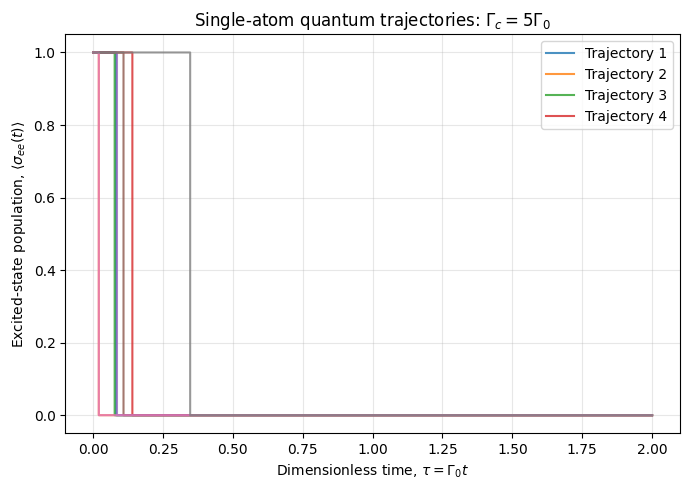

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\single_atom_individual_trajectories.png


In [8]:
#plot-individual-quantum-trajectories
plt.figure(figsize=(7, 5))

for traj_index in range(num_individual_trajectories):
    plt.step(
        tau_grid,
        individual_trajectories[traj_index],
        where="post",
        linewidth=1.5,
        alpha=0.8,
        label=f"Trajectory {traj_index + 1}" if traj_index < 4 else None,
    )

plt.xlabel(r"Dimensionless time, $\tau = \Gamma_0 t$")
plt.ylabel(r"Excited-state population, $\langle \sigma_{ee}(t) \rangle$")
plt.title(r"Single-atom quantum trajectories: $\Gamma_c = 5\Gamma_0$")
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "single_atom_individual_trajectories.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [9]:
#run-trajectory-averages
trajectory_counts = [10, 100, 1000, 5000]

#trajectory-averages-storage-calc
trajectory_averages = {}

#random-number-generator-for-averages
rng = np.random.default_rng(seed=2026)

for num_trajectories in trajectory_counts:
    
    #population-sum-storage-calc
    population_sum = np.zeros(len(t_grid))
    
    for traj_index in range(num_trajectories):
        trajectory = run_single_trajectory(
            t_grid=t_grid,
            initial_state=psi0,
            jump_operator=jump_operator,
            jump_rate_operator=jump_rate_operator,
            sigma_ee=sigma_ee,
            rng=rng,
        )
        
        #accumulate-trajectory-calc
        population_sum += trajectory
    
    #average-trajectories-calc
    trajectory_averages[num_trajectories] = population_sum / num_trajectories
    
    print(f"Completed {num_trajectories} trajectories.")

Completed 10 trajectories.
Completed 100 trajectories.
Completed 1000 trajectories.
Completed 5000 trajectories.


In [10]:
#analytical-reference-calc
pop_excited_analytical = np.exp(-gamma_total * t_grid)

#dimensionless-form-check
pop_excited_analytical_tau = np.exp(-(1 + alpha) * tau_grid)

#sanity-check-analytical-equivalence
print("Max difference between t and tau analytical expressions:",
      np.max(np.abs(pop_excited_analytical - pop_excited_analytical_tau)))

Max difference between t and tau analytical expressions: 0.0


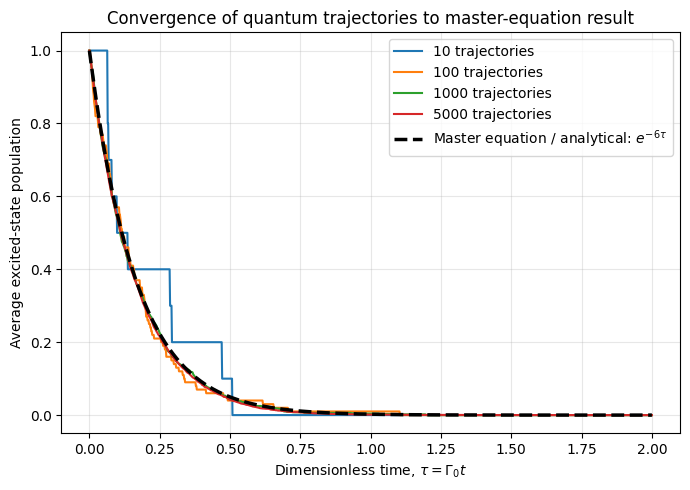

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\single_atom_trajectory_convergence.png


In [11]:
#plot-trajectory-convergence
plt.figure(figsize=(7, 5))

for num_trajectories in trajectory_counts:
    plt.plot(
        tau_grid,
        trajectory_averages[num_trajectories],
        linewidth=1.5,
        label=f"{num_trajectories} trajectories",
    )

plt.plot(
    tau_grid,
    pop_excited_analytical,
    "k--",
    linewidth=2.5,
    label=r"Master equation / analytical: $e^{-6\tau}$",
)

plt.xlabel(r"Dimensionless time, $\tau = \Gamma_0 t$")
plt.ylabel(r"Average excited-state population")
plt.title(r"Convergence of quantum trajectories to master-equation result")
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "single_atom_trajectory_convergence.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [12]:
#trajectory-convergence-error-table
error_rows = []

for num_trajectories in trajectory_counts:
    average_population = trajectory_averages[num_trajectories]
    
    #mean-absolute-error-calc
    mean_abs_error = np.mean(np.abs(average_population - pop_excited_analytical))
    
    #max-absolute-error-calc
    max_abs_error = np.max(np.abs(average_population - pop_excited_analytical))
    
    error_rows.append({
        "Number of trajectories": num_trajectories,
        "Mean absolute error": mean_abs_error,
        "Maximum absolute error": max_abs_error,
    })

error_table = pd.DataFrame(error_rows)
error_table

,Number of trajectories,Mean absolute error,Maximum absolute error
0,10,0.028802,0.316355
1,100,0.006250,0.058000
2,1000,0.002136,0.024288
3,5000,0.003180,0.017336


In [13]:
#report-note-single-atom-trajectories
print(
    "The quantum trajectory simulation produces stochastic single-shot decay paths. "
    "Each trajectory remains in the excited state until a randomly sampled quantum jump occurs, "
    "after which the atom is projected into the ground state. Averaging over many trajectories "
    "recovers the master-equation prediction for the excited-state population. "
    "For Gamma_c = 5 Gamma_0, the trajectory average converges towards exp(-6 tau), "
    "consistent with the result obtained from the density-matrix master equation."
)

The quantum trajectory simulation produces stochastic single-shot decay paths. Each trajectory remains in the excited state until a randomly sampled quantum jump occurs, after which the atom is projected into the ground state. Averaging over many trajectories recovers the master-equation prediction for the excited-state population. For Gamma_c = 5 Gamma_0, the trajectory average converges towards exp(-6 tau), consistent with the result obtained from the density-matrix master equation.
